# Entrega 2 — Detecção de Duplicatas Semânticas
Cerca de 15% das manifestações descrevem o mesmo problema com palavras diferentes. Aqui construímos `detectar_duplicatas(textos, limiar=0.85)`, mostramos a matriz de similaridade completa, justificamos o limiar e medimos falsos positivos e falsos negativos contra o gabarito (`data/duplicatas_gabarito.json`).

In [1]:
import json
import os
import warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # evita aviso do joblib no Windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

with open("data/manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)
df = pd.DataFrame(manifestacoes)
idx = {m: i for i, m in enumerate(df["id"])}
print(df.shape)
df.head()

(40, 4)


,id,data,categoria_oficial,texto
0,M001,2026-03-02,infraestrutura,"Calçada toda quebrada na Rua das Flores, perto do número 120. Dois idosos já caíram tentando passar por ali e ningué..."
1,M002,2026-03-02,saúde,Fiquei mais de cinco horas esperando atendimento na UPA do Centro com meu filho de dois anos com febre alta. Só havi...
2,M003,2026-03-03,infraestrutura,"Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estouraram o pneu e um mot..."
3,M004,2026-03-03,segurança,"Os moradores da Rua Sete estão com medo porque aconteceram três assaltos nesta semana na esquina da padaria, sempre ..."
4,M005,2026-03-04,infraestrutura,A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagados há mais de um mês.


In [2]:
with open("data/duplicatas_gabarito.json", encoding="utf-8") as f:
    gabarito = {tuple(sorted(p)) for p in json.load(f)}
print("Pares duplicados reais:", sorted(gabarito))

MODELO = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = SentenceTransformer(MODELO)
emb = modelo.encode(df["texto"].tolist(), normalize_embeddings=True)
S = cosine_similarity(emb)

Pares duplicados reais: [('M003', 'M017'), ('M005', 'M026'), ('M008', 'M022'), ('M011', 'M029'), ('M014', 'M035'), ('M019', 'M038')]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 1) A função `detectar_duplicatas`

In [3]:
def detectar_duplicatas(textos, limiar=0.85, modelo=modelo, ids=None):
    """Retorna todos os pares (id_a, id_b, similaridade) com cosseno >= limiar.

    textos : lista de strings
    limiar : similaridade de cosseno mínima para considerar duplicata
    ids    : rótulos dos textos (padrão: posição na lista)
    """
    ids = ids if ids is not None else list(range(len(textos)))
    E = modelo.encode(list(textos), normalize_embeddings=True)
    sim = E @ E.T  # vetores normalizados: produto escalar = cosseno
    pares = []
    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):
            if sim[i, j] >= limiar:
                pares.append((ids[i], ids[j], round(float(sim[i, j]), 4)))
    return sorted(pares, key=lambda p: p[2], reverse=True)

detectar_duplicatas(df["texto"], limiar=0.85, ids=df["id"].tolist())

[]

## 2) Matriz de similaridade completa (heatmap 40 × 40)

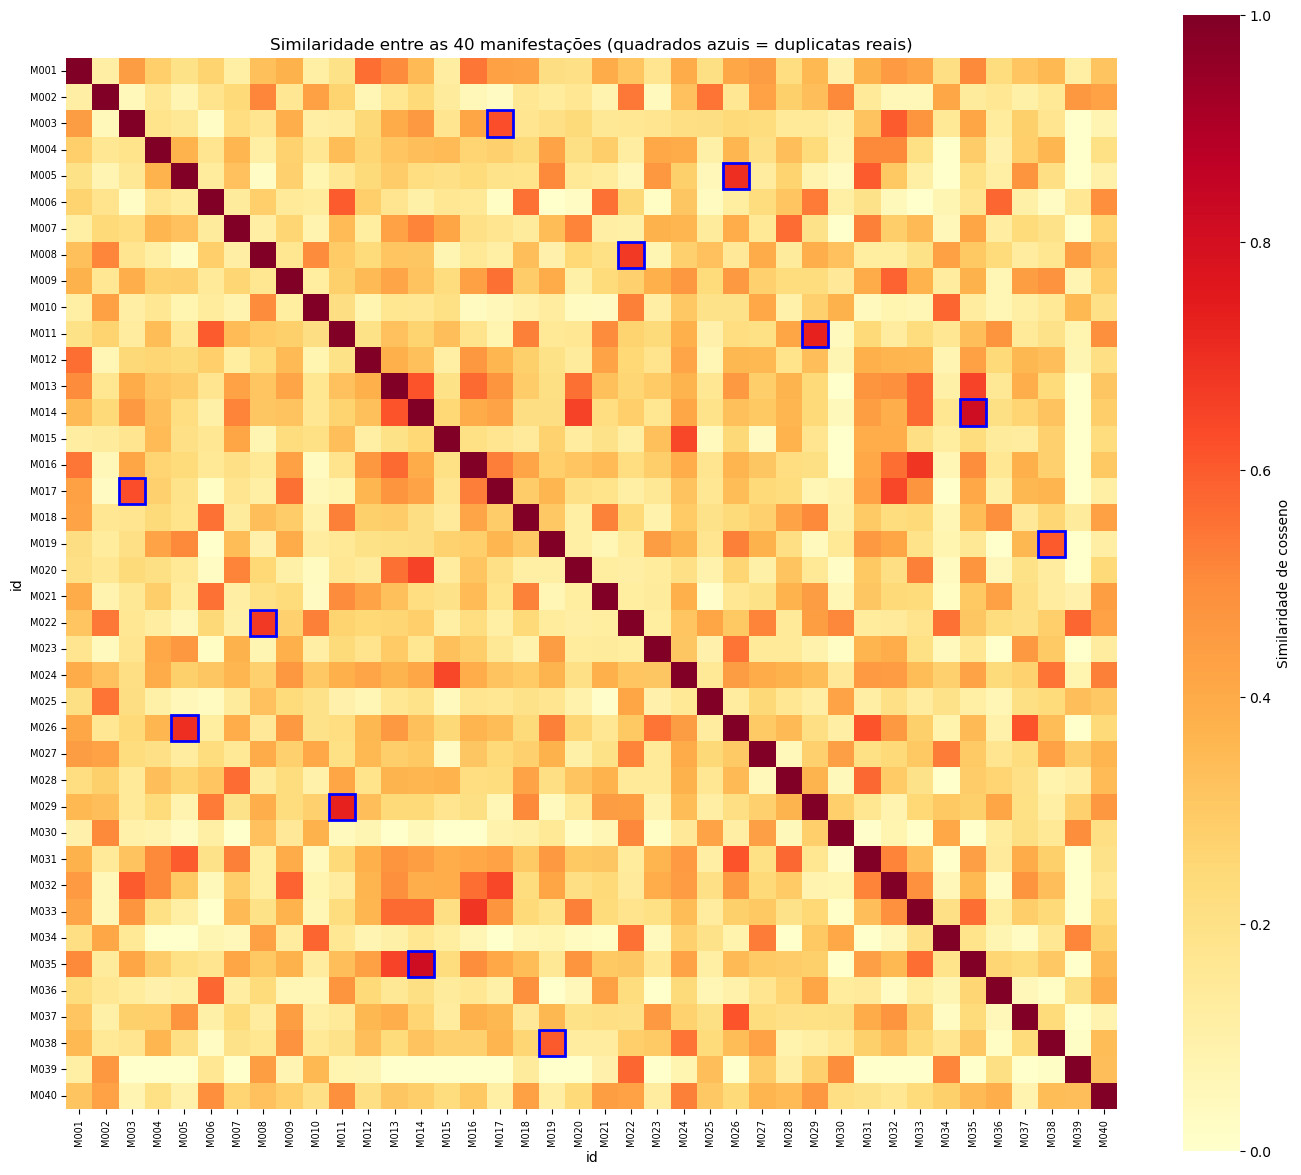

In [4]:
plt.figure(figsize=(14, 12))
sns.heatmap(pd.DataFrame(S, index=df["id"], columns=df["id"]), cmap="YlOrRd", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Similaridade de cosseno"}, xticklabels=True, yticklabels=True)
for a, b in gabarito:  # contorna os pares do gabarito
    for (r, c) in [(idx[a], idx[b]), (idx[b], idx[a])]:
        plt.gca().add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="blue", lw=2))
plt.title("Similaridade entre as 40 manifestações (quadrados azuis = duplicatas reais)")
plt.xticks(fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

## 3) Escolha do limiar
Duas evidências: (a) a **distribuição** das similaridades entre pares (o enunciado sugere um limiar dinâmico por percentil) e (b) uma **varredura** de limiares medindo precisão, recall e F1 contra o gabarito.

Total de pares: 780 | duplicatas reais: 6
Percentil 90: 0.473
Percentil 95: 0.536
Percentil 99: 0.643
Menor similaridade entre duplicatas reais: 0.602
Maior similaridade entre NÃO duplicatas:   0.685


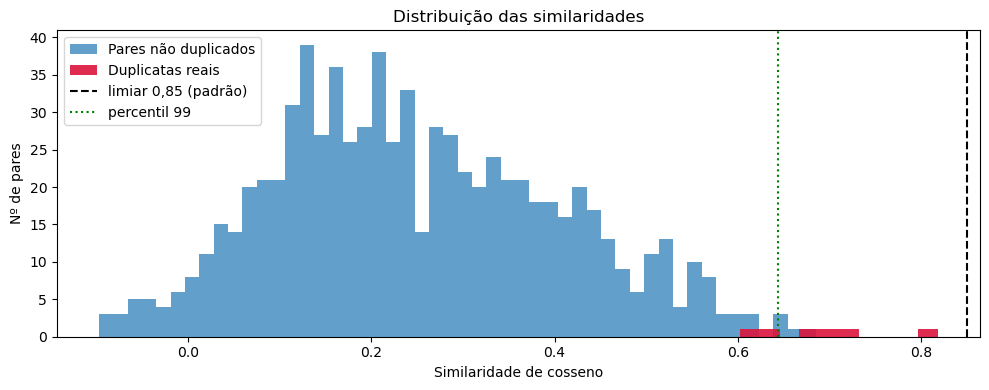

In [5]:
iu = np.triu_indices(len(df), k=1)
sims = S[iu]
eh_dup = np.array([tuple(sorted((df["id"][i], df["id"][j]))) in gabarito for i, j in zip(*iu)])

print(f"Total de pares: {len(sims)} | duplicatas reais: {eh_dup.sum()}")
for p in [90, 95, 99]:
    print(f"Percentil {p}: {np.percentile(sims, p):.3f}")
print(f"Menor similaridade entre duplicatas reais: {sims[eh_dup].min():.3f}")
print(f"Maior similaridade entre NÃO duplicatas:   {sims[~eh_dup].max():.3f}")

plt.figure(figsize=(10, 4))
plt.hist(sims[~eh_dup], bins=50, alpha=0.7, label="Pares não duplicados")
plt.hist(sims[eh_dup], bins=10, alpha=0.9, color="crimson", label="Duplicatas reais")
plt.axvline(0.85, color="black", ls="--", label="limiar 0,85 (padrão)")
plt.axvline(np.percentile(sims, 99), color="green", ls=":", label="percentil 99")
plt.xlabel("Similaridade de cosseno"); plt.ylabel("Nº de pares"); plt.legend()
plt.title("Distribuição das similaridades"); plt.tight_layout(); plt.show()

In [6]:
linhas = []
for lim in np.round(np.arange(0.50, 0.96, 0.025), 3):
    pred = sims >= lim
    vp, fp, fn = int((pred & eh_dup).sum()), int((pred & ~eh_dup).sum()), int((~pred & eh_dup).sum())
    prec = vp / (vp + fp) if vp + fp else 0.0
    rec = vp / (vp + fn)
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    linhas.append({"Limiar": lim, "VP": vp, "FP": fp, "FN": fn,
                   "Precisão": round(prec, 3), "Recall": round(rec, 3), "F1": round(f1, 3)})
varredura = pd.DataFrame(linhas)
melhor = varredura.loc[varredura["F1"].idxmax()]
print(f"Melhor F1 = {melhor['F1']} no limiar {melhor['Limiar']}")
varredura

Melhor F1 = 0.667 no limiar 0.65


,Limiar,VP,FP,FN,Precisão,Recall,F1
0,0.500,6,59,0,0.092,1.000,0.169
1,0.525,6,41,0,0.128,1.000,0.226
2,0.550,6,29,0,0.171,1.000,0.293
3,0.575,6,15,0,0.286,1.000,0.444
4,0.600,6,10,0,0.375,1.000,0.545
5,0.625,5,5,1,0.500,0.833,0.625
6,0.650,4,2,2,0.667,0.667,0.667
7,0.675,3,1,3,0.750,0.500,0.600
8,0.700,2,0,4,1.000,0.333,0.500
9,0.725,2,0,4,1.000,0.333,0.500


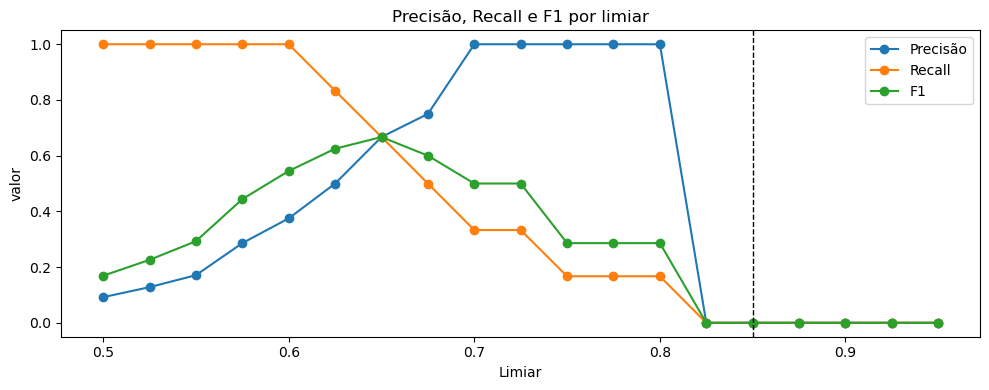

In [7]:
ax = varredura.plot(x="Limiar", y=["Precisão", "Recall", "F1"], figsize=(10, 4), marker="o")
ax.axvline(0.85, color="black", ls="--", lw=1)
ax.set_title("Precisão, Recall e F1 por limiar"); ax.set_ylabel("valor")
plt.tight_layout(); plt.show()

## 4) Pares encontrados e análise de erros

In [8]:
LIMIAR_ESCOLHIDO = float(melhor["Limiar"])
texto = dict(zip(df["id"], df["texto"]))

def avaliar(limiar):
    achados = detectar_duplicatas(df["texto"], limiar=limiar, ids=df["id"].tolist())
    achados_set = {tuple(sorted(p[:2])) for p in achados}
    vp = [p for p in achados if tuple(sorted(p[:2])) in gabarito]
    fp = [p for p in achados if tuple(sorted(p[:2])) not in gabarito]
    fn = [(a, b, round(float(S[idx[a], idx[b]]), 4)) for a, b in sorted(gabarito) if (a, b) not in achados_set]
    return vp, fp, fn

for limiar in [0.85, LIMIAR_ESCOLHIDO]:
    vp, fp, fn = avaliar(limiar)
    print(f"\n===== Limiar {limiar} =====  VP={len(vp)}  FP={len(fp)}  FN={len(fn)}")
    for nome, lista in [("Verdadeiros positivos", vp), ("Falsos positivos", fp), ("Falsos negativos", fn)]:
        print(f"-- {nome}:")
        for a, b, s in lista:
            print(f"   {a} × {b}  (cos = {s})")
            print(f"      {a}: {texto[a][:110]}")
            print(f"      {b}: {texto[b][:110]}")


===== Limiar 0.85 =====  VP=0  FP=0  FN=6
-- Verdadeiros positivos:
-- Falsos positivos:
-- Falsos negativos:
   M003 × M017  (cos = 0.626)
      M003: Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estouraram o pneu e 
      M017: O asfalto todo esburacado da avenida principal está causando acidentes. Precisa de recapeamento urgente, os ca
   M005 × M026  (cos = 0.7)
      M005: A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagados há mais de um
      M026: Poste sem luz na Rua Pernambuco. À noite a rua vira um breu e ninguém consegue ver nada, já pedimos a troca da
   M008 × M022  (cos = 0.674)
      M008: O posto de saúde do Jardim América está sem médico há duas semanas. As pessoas vão até lá e voltam para casa s
      M022: Falta atendimento no PSF do meu bairro. Não tem doutor para consultar e mandam a gente voltar outro dia, mas n
   M011 × M029  (cos = 0.7309)
      M011: Os alunos da Escola 


===== Limiar 0.65 =====  VP=4  FP=2  FN=2
-- Verdadeiros positivos:
   M014 × M035  (cos = 0.8182)
      M014: Há lixo acumulado no terreno baldio da Rua Goiás há meses. O mato está alto, tem rato e o mau cheiro está insu
      M035: Terreno abandonado na Rua Goiás cheio de lixo e entulho. Aparecem ratos e baratas nas casas vizinhas e ninguém
   M011 × M029  (cos = 0.7309)
      M011: Os alunos da Escola Paulo Freire estão sem merenda escolar há uma semana. Muitas crianças só fazem uma refeiçã
      M029: As crianças da Escola Paulo Freire não estão recebendo lanche há vários dias porque a merenda acabou e não che
   M005 × M026  (cos = 0.7)
      M005: A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagados há mais de um
      M026: Poste sem luz na Rua Pernambuco. À noite a rua vira um breu e ninguém consegue ver nada, já pedimos a troca da
   M008 × M022  (cos = 0.674)
      M008: O posto de saúde do Jardim América está sem médico há duas se

## 5) Justificativa do limiar e análise de erros

**O limiar padrão 0,85 não funciona nesta base.** Nenhum par chega a 0,85: a maior similaridade entre duplicatas reais é 0,818 (M014 × M035). Com 0,85 a função devolve lista vazia (0 VP e 6 FN). Isso acontece porque o modelo `paraphrase-multilingual-MiniLM-L12-v2` gera cossenos mais baixos para paráfrases que usam vocabulário muito diferente ("buraco enorme" × "asfalto todo esburacado").

**Limiar escolhido: 0,65.** Três evidências apontam para ele:
1. **Varredura contra o gabarito:** o F1 máximo (0,667) está em 0,65, com precisão e recall de 0,667 (4 VP, 2 FP, 2 FN).
2. **Limiar dinâmico por percentil:** o percentil 99 da distribuição dos 780 pares é 0,643, praticamente o mesmo valor. Isso importa porque, em produção, não existe gabarito, e o percentil pode ser recalculado a cada lote de manifestações.
3. **Distribuição:** o histograma mostra que as duplicatas ficam na cauda direita (0,60 a 0,82), enquanto a massa de pares não duplicados está abaixo de 0,55.

Trade-off: 0,60 encontra as 6 duplicatas (recall 1,0) com 10 falsos positivos; 0,70 tem precisão 1,0 mas só acha 2. Para uma ouvidoria, **perder uma duplicata custa pouco** (a manifestação só é tratada em separado), enquanto **fundir manifestações diferentes** pode fazer um problema real ser ignorado. Por isso, o sistema deve **sugerir** os pares acima de 0,65 para um atendente confirmar, e não fundi-los automaticamente.

**Falsos positivos (limiar 0,65):**
- **M016 × M033 (0,686):** ponte de madeira no Sítio Várzea × entulho no Rio Jaguaribe. São os dois textos longos que falam de rio/riacho, ponte, cheia e comunidade isolada. O vocabulário do cenário é parecido, mas os problemas são diferentes (infraestrutura × descarte irregular). Textos longos misturam vários assuntos num único vetor, e é esse o motivo da Entrega 3 (chunking).
- **M014 × M020 (0,655):** lixo no terreno baldio × esgoto no córrego. Mesmo tema (meio ambiente/saneamento, mau cheiro), mas locais e problemas diferentes. É um erro "vizinho": agrupar os dois num mesmo cluster seria correto, marcar como duplicata não.

**Falsos negativos:**
- **M003 × M017 (0,626):** a M003 cita um local específico (Av. Brasil, supermercado) e um efeito (pneu estourado); a M017 fala de "avenida principal", recapeamento e acidentes. O modelo não sabe que a "avenida principal" é a Av. Brasil. Só um humano ou a geolocalização da manifestação resolveria.
- **M019 × M038 (0,602):** "assaltos frequentes no ponto de ônibus" × "alguém é roubado na parada de ônibus". Sinônimos regionais (ponto × parada) e a mudança de voz ("assaltos" × "é roubado") reduzem a similaridade.

**Melhorias possíveis:** comparar também os nomes de logradouros extraídos (busca léxica), usar um modelo maior (ex.: `BAAI/bge-m3`) ou reranquear os candidatos com um cross-encoder.